# HW 5 Jupyter Notebook

## Please Run the cell below before you begin working on this Homework!

In [1]:
# First we need to import all of the packages we will be using!
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

## Part 1: NFκB signaling Model

In [8]:
# NFKB - IKBa model
def NFKB_model(states, t, IKK_on, IKK_off, IKK_amp):
    # states = [NFKB, IKBa, NFKB:IKBa, prIKBa, NFKB:prIKBa]
    NFKB = states[0]
    IKBa = states[1]
    NFKB_IKBa = states[2]
    prIKBa = states[3]
    NFKB_prIKBa = states[4]
    
    # delayed variables
    prIKBa_tau = delay_prIKBa(t)
    NFKB_prIKBa_tau = delay_NFKB_prIKBa(t)
    
    # IKK activation
    if (t > IKK_on) and (t < IKK_off):
        IKK = IKK_amp
    else:
        IKK = 0

    # change equations (mass-action + delays for synthesis)
    NFKB_prime = (
        -k_a*NFKB*IKBa
        + k_d*NFKB_IKBa
        + r*IKK*NFKB_IKBa
        - f_a*NFKB*prIKBa
        + f_d*NFKB_prIKBa
    )
    IKBa_prime = (
        -k_a*NFKB*IKBa
        + k_d*NFKB_IKBa
        - r*IKK*IKBa
        - g*IKBa
        + a*prIKBa_tau
        + b*NFKB_prIKBa_tau
    )
    NFKB_IKBa_prime = (
        k_a*NFKB*IKBa
        - k_d*NFKB_IKBa
        - r*IKK*NFKB_IKBa
    )
    prIKBa_prime = (
        -f_a*NFKB*prIKBa
        + f_d*NFKB_prIKBa
    )
    NFKB_prIKBa_prime = (
        f_a*NFKB*prIKBa
        - f_d*NFKB_prIKBa
    )
    
    statesprime = [NFKB_prime, IKBa_prime, NFKB_IKBa_prime, prIKBa_prime, NFKB_prIKBa_prime]
    return statesprime


In [9]:
#delay helper functions

#these helper functions search through the ODE solution from the previous iteration 
#to give approximations of prIKBa_tau and NFKB_prIKBa_tau as needed

def delay_prIKBa(t_search):
    index = np.argmin(abs(t_search-t_index))
    return soln_hist[index, 3]
def delay_NFKB_prIKBa(t_search):
    index = np.argmin(abs(t_search-t_index))
    return soln_hist[index, 4]  

In [10]:
# Steady State Simulation  (tau = 10)

# initial condition constraints
NFKB_0 = 100 #(nM)
IKBa_0 = 0
NFKB_IKBa_0 = 0 
prIKBa_0 = 1
NFKB_prIKBa_0 = 0

# parameters
k_a = 0.1  #(nM*min)^-1
k_d = 0.0006  #(min)^-1
r   = 0.01
g   = 0.012
f_a = 10
f_d = 200
a   = 0.00185
b   = 5
tau = 25  # CHANGED HERE

# IKK activation (off for steady state)
IKK_on_time  = 0
IKK_off_time = 0
IKK_amplitude = 0

t_final = np.array([])
soln_final = np.empty((0, 5))
states0 = [NFKB_0, IKBa_0, NFKB_IKBa_0, prIKBa_0, NFKB_prIKBa_0]

# provide initial history for delay lookups
soln_hist = np.tile(states0, (1001, 1))

iterations = 20  # default

for i in range(iterations):
    # solve ODE over one delay window
    t_index = np.linspace(0, tau, 1001)
    solution = odeint(NFKB_model, states0, t_index, args=(IKK_on_time, IKK_off_time, IKK_amplitude))
    
    # append (exclude last point to avoid duplication across windows)
    t_final = np.append(t_final, (t_index[0:1000] + i*tau))
    soln_final = np.vstack((soln_final, solution[0:1000, :]))
    
    # update ICs and history
    states0 = solution[1000, :]
    soln_hist = solution

steady_state = soln_final[(iterations*1000)-1, :]
print("tau = 10 min, steady_state =", steady_state)


tau = 10 min, steady_state = [1.66556169e-01 3.59586847e+00 9.98251848e+01 9.91740972e-01
 8.25902796e-03]


In [11]:
#Checking Model Implementation
#checks only work on default parameter values
print("Checks on Model Implementation:")
print("For each of the following lines ensure that your value on the right matches that on the left for the first 4 decimal places")
print(48.225059139469735, soln_final[1500, 0])
print(96.78765543513467, soln_final[2000, 2])
print(52.60671701101044, soln_final[4000, 1])
print(16.23230531035957, soln_final[8000, 1])
print(0.9981694760165793, soln_final[8000, 3])

Checks on Model Implementation:
For each of the following lines ensure that your value on the right matches that on the left for the first 4 decimal places
48.225059139469735 48.22505909022428
96.78765543513467 96.78765558229689
52.60671701101044 52.60671140091935
16.23230531035957 16.232297235601617
0.9981694760165793 0.9981694749930791


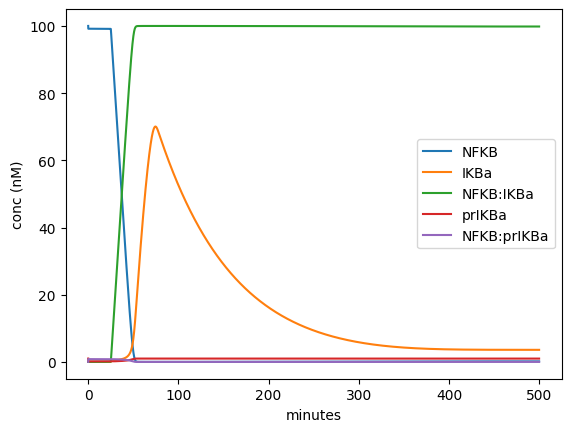

In [12]:
#Plot Dynamics - ensure steady state is reached by end of simulation
lineObjects=plt.plot(t_final, soln_final)
plt.xlabel('minutes')
plt.ylabel('conc (nM)')
plt.legend(lineObjects, ('NFKB', 'IKBa', 'NFKB:IKBa', 'prIKBa', 'NFKB:prIKBa'))

## Part 2: NFκB responses to IKK duration

In [13]:
# NFKB responses to IKK activation

def NFKB_response(IKK_on_time, IKK_off_time, IKK_amplitude):

    IKK_on = IKK_on_time
    IKK_off = IKK_off_time
    IKK_amp = IKK_amplitude
    
    t_final=np.array([])
    soln_final = np.empty((0, 5))
    states0 = steady_state
    global soln_hist
    soln_hist = np.tile(steady_state, (1001, 1))

    iterations = 20

    for i in range(iterations):
        # solve ODE in one period of tau, using saved values of delayed variables
        global t_index
        t_index = np.linspace(0,tau,1001)
        solution = odeint(NFKB_model,states0,t_index,args=(IKK_on, IKK_off, IKK_amp))

        # append new solution to array of old solution values
        t_final = np.append(t_final, (t_index[0:1000]+i*tau))
        soln_final = np.vstack((soln_final, solution[0:1000, :]))

        #update IKK_on/off times, initial conditions, and solution history for next calculation
        IKK_on = IKK_on - tau
        IKK_off = IKK_off - tau
        states0 = solution[1000, :]
        soln_hist = solution

    return (t_final, soln_final)

In [14]:
# Duration of NFKB response versus IKK duration
IKK_duration = [0, 0.25, 0.5, 1, 2, 5, 10, 20, 30, 60, 120] #minutes of IKK activation
NFKB_duration = [0]
NFKB_threshold = 1
for dur in IKK_duration[1:]: 
    time, soln = NFKB_response(0, dur, 10)
    count = 0
    while soln[count, 0]<NFKB_threshold:
        count = count + 1
    start = count
    while soln[count, 0]>NFKB_threshold:
        count = count + 1
    end = count
    NFKB_duration = np.append(NFKB_duration, time[end]-time[start])


Text(0, 0.5, 'Duration of NFKB response (minutes)')

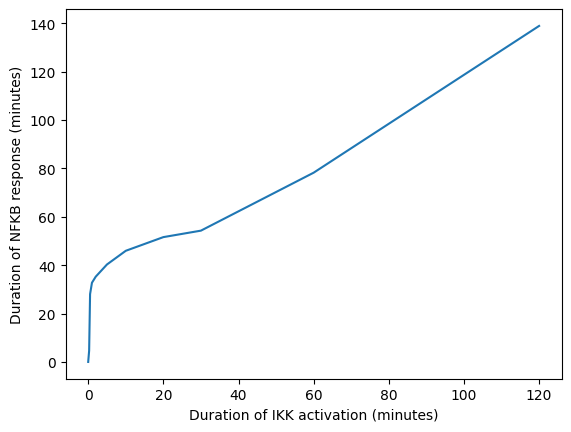

In [15]:
# Plot IKK activation versus NFKB response duration
plt.plot(IKK_duration, NFKB_duration )
plt.xlabel("Duration of IKK activation (minutes)")
plt.ylabel("Duration of NFKB response (minutes)")

## Part 3: NFκB responses to IKK amplitude

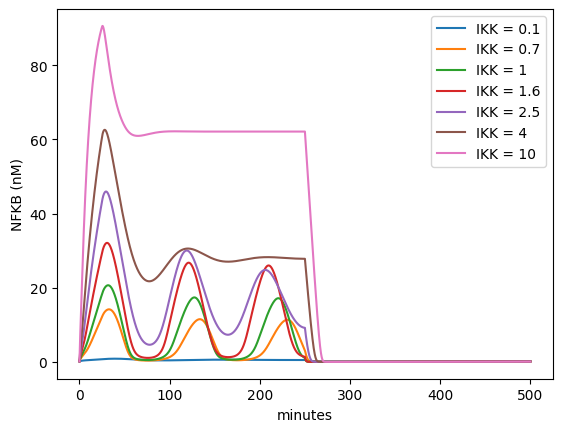

In [16]:
# NFKB response versus amplitude of IKK activation (1)

# running with different amplitudes 
amps = [0.1, 0.7, 1, 1.6, 2.5, 4, 10]

plt.figure()
for amp in amps:
    time, soln = NFKB_response(0, 250, amp)
    plt.plot(time, soln[:, 0], label=f'IKK = {amp}')
plt.xlabel('minutes')
plt.ylabel('NFKB (nM)')
plt.legend()
plt.show()


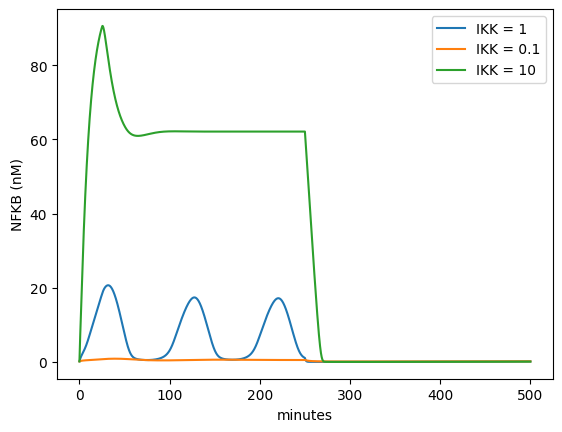

In [28]:
# NFKB response versus amplitude of IKK activation (2)
time, soln1 = NFKB_response(0, 250, 1)
time, soln2 = NFKB_response(0, 250, 0.1)
time, soln3 = NFKB_response(0, 250, 10)

plt.plot(time, soln1[:, 0], label='IKK = 1')
plt.plot(time, soln2[:, 0], label='IKK = 0.1')
plt.plot(time, soln3[:, 0], label='IKK = 10')
plt.xlabel('minutes')
plt.ylabel('NFKB (nM)')
plt.legend()

In [43]:
# Oscillation strength of NFKB response versus IKK amplitude (this takes a while to run)
IKK_amplitude = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1, 1.3, 1.6, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]
NFKB_peak_ratio = [0]
print(NFKB_peak_ratio)
for amp in IKK_amplitude[1:]: 
    time, soln = NFKB_response(0, 250, amp)
    peaks, _ = find_peaks(soln[:, 0], distance=1)
    troughs, _ = find_peaks(-soln[:, 0], distance=1)
    rat = (soln[peaks[1], 0]-soln[troughs[1], 0]) / (soln[peaks[0], 0]-soln[troughs[0], 0]) # 2nd peak prominence / 1st peak
    NFKB_peak_ratio = np.append(NFKB_peak_ratio, rat)

[0]


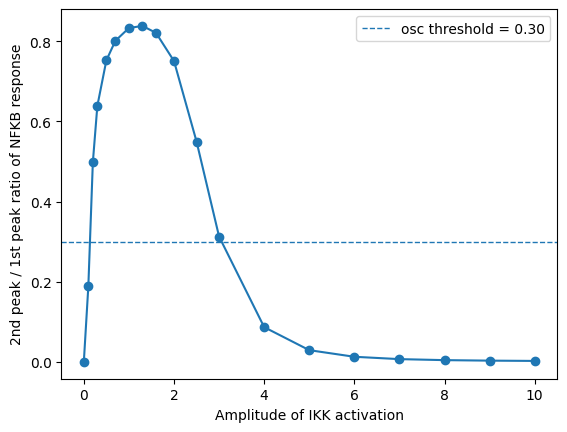

Oscillatory amplitudes: [0.2, 0.3, 0.5, 0.7, 1, 1.3, 1.6, 2, 2.5, 3]
Non-oscillatory amplitudes: [0, 0.1, 4, 5, 6, 7, 8, 9, 10]


In [44]:
# Plot IKK amplitude versus NFKB response oscillation
plt.plot(IKK_amplitude, NFKB_peak_ratio, marker='o')
plt.xlabel("Amplitude of IKK activation")
plt.ylabel("2nd peak / 1st peak ratio of NFKB response")

# THRESHOLD LINE for Q12
osc_threshold = 0.30
plt.axhline(osc_threshold, linestyle='--', linewidth=1, label='osc threshold = 0.30')
plt.legend()
plt.show()

# Optional classification printout
osc_amps = [IKK_amplitude[i] for i, r in enumerate(NFKB_peak_ratio) if r >= osc_threshold]
non_osc_amps = [IKK_amplitude[i] for i, r in enumerate(NFKB_peak_ratio) if r < osc_threshold]
print("Oscillatory amplitudes:", osc_amps)
print("Non-oscillatory amplitudes:", non_osc_amps)